In [1]:
!pip install matplotlib seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from pandas import DataFrame
from bs4 import BeautifulSoup
import os
from concurrent.futures import ThreadPoolExecutor

Defaulting to user installation because normal site-packages is not writeable


In [2]:
url = "https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/"
response = requests.get(url)

In [3]:
htmlresponse = response.text
print(htmlresponse)

<!DOCTYPE html PUBLIC "-//W3C//DTD HTML 3.2 Final//EN">
<html>
<head>
<meta http-equiv="Content-Type" content="text/html; charset=UTF-8">
<title>Index of /pub/data/swdi/stormevents/csvfiles/</title>
</head>
<body>
<h1>Index of /pub/data/swdi/stormevents/csvfiles/</h1>
<table><tbody>
<tr>
<th>Name</th>
<th>Last modified</th>
<th>Size</th>
<th>Description</th>
</tr>
<tr><th colspan="4"><hr></th></tr>
<tr>
<td><a href="..">Parent Directory</a></td>
<td> </td>
<td align="right">-</td>
<td> </td>
</tr>
<tr>
<td><a href="legacy">legacy/</a></td>
<td align="right">2014-05-14 11:00</td>
<td align="right">-</td>
<td> </td>
</tr>
<tr>
<td><a href=".Storm-Data-Export-Format.docx.old">.Storm-Data-Export-Format.docx.old</a></td>
<td align="right">2014-05-06 21:49</td>
<td align="right">23834</td>
<td> </td>
</tr>
<tr>
<td><a href="README">README</a></td>
<td align="right">2026-03-24 12:05</td>
<td align="right">2013</td>
<td> </td>
</tr>
<tr>
<td><a href="Storm-Data-Bulk-csv-Format.pdf">Storm-Data-

In [4]:
soupobject = BeautifulSoup(htmlresponse, 'html.parser')
parent_tag = soupobject.find_all('a')
csv_urls = []
csvdetails_url = []
for tag in parent_tag:
    href = tag.get('href')

    if href and href.endswith('csv.gz'):
        full_url = url + href
        csv_urls.append(full_url)
for url in csv_urls:
    if 'details' in url:
        onlydetails = url
        csvdetails_url.append(onlydetails)

print(csvdetails_url)


['https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d1950_c20260323.csv.gz', 'https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d1951_c20260323.csv.gz', 'https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d1952_c20260323.csv.gz', 'https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d1953_c20260323.csv.gz', 'https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d1954_c20260323.csv.gz', 'https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d1955_c20260323.csv.gz', 'https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d1956_c20260323.csv.gz', 'https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d1957_c20260323.csv.gz', 'https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEven

In [5]:
dates_1996to2024 = []
for year in csvdetails_url:
    date = int(year[91:95])
    if date > 1995 and date < 2025:
        dates_1996to2024.append(year)
print(dates_1996to2024)

['https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d1996_c20260323.csv.gz', 'https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d1997_c20260323.csv.gz', 'https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d1998_c20260323.csv.gz', 'https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d1999_c20260323.csv.gz', 'https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d2000_c20260323.csv.gz', 'https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d2001_c20260323.csv.gz', 'https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d2002_c20260323.csv.gz', 'https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEvents_details-ftp_v1.0_d2003_c20260323.csv.gz', 'https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/StormEven

In [6]:
output_folder = "zipped_data"
os.makedirs(output_folder, exist_ok=True)
def download_files(url):
    filename = url[91:95]
    local_path = os.path.join(output_folder, filename)
    if os.path.exists(local_path):
        return f"Skipped: {filename} (Already exists)"
    try:
        response = requests.get(url, timeout=30)
        if response.status_code == 200:
            with open(local_path, "wb") as local_file:
                local_file.write(response.content)
            return f"Successfully downloaded {filename}"
        else:
            return f"Failed: {filename} (Status {response.status_code})"
    except Exception as e:
        return f"Error downloading {filename}: {e}"
    
max_simultaneous_downloads = 8

with ThreadPoolExecutor(max_workers=max_simultaneous_downloads) as executor:
    results = executor.map(download_files, dates_1996to2024)
    

    





In [8]:
columns_wanted = ['BEGIN_YEARMONTH', 'BEGIN_DAY', 'END_YEARMONTH', 'END_DAY', 'EVENT_ID', 'STATE', 'CZ_NAME', 'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON', 'EVENT_TYPE']
rows_wanted = ['IOWA', 'FLOOD', 'FLASH FLOOD']
def extract_NOAA_data():
    filtered = []
    for i in range(1996,2025):
        full_path = os.path.join('zipped_data', str(i))
        df = pd.read_csv(full_path, compression='gzip',usecols=columns_wanted)
        filter_IAFLOODS = df[(df['STATE'] == 'IOWA') & (df['EVENT_TYPE'].isin(['Flood', 'Flash Flood']))]
        filtered.append(filter_IAFLOODS)
    return filtered

allIowaFloods_1996to2024 = extract_NOAA_data()

IowaFloods_96to24 = pd.concat(allIowaFloods_1996to2024, ignore_index=True)

IowaFloods_96to24.to_csv('IowaFloods_96to24.csv', index=False)
                         


In [9]:
def convert_damage(value):
    value = str(value)
    if 'K' in value:
        return float(value.replace('K', '')) * 0.001
    elif 'M' in value:
        return float(value.replace('M', ''))
    elif 'B' in value:
        return float(value.replace('B', '')) * 1000
    

def normalize_propdamage_amount():
    IowaFloods_96to24['DAMAGE_PROPERTY'] = IowaFloods_96to24['DAMAGE_PROPERTY'].apply(convert_damage)
    IowaFloods_96to24['DAMAGE_PROPERTY'] = IowaFloods_96to24['DAMAGE_PROPERTY'].fillna(0)
normalize_propdamage_amount()
print(IowaFloods_96to24['DAMAGE_PROPERTY'])   
    


0       0.00
1       0.00
2       0.05
3       0.00
4       0.00
        ... 
7271    0.00
7272    0.55
7273    0.00
7274    0.00
7275    0.00
Name: DAMAGE_PROPERTY, Length: 7276, dtype: float64


In [10]:
def convert_damage(value):
    value = str(value)
    if 'K' in value:
        return float(value.replace('K', '')) * 0.001
    elif 'M' in value:
        return float(value.replace('M', ''))
    elif 'B' in value:
        return float(value.replace('B', '')) * 1000
    

def normalize_propdamage_amount():
    IowaFloods_96to24['DAMAGE_CROPS'] = IowaFloods_96to24['DAMAGE_CROPS'].apply(convert_damage)
    IowaFloods_96to24['DAMAGE_CROPS'] = IowaFloods_96to24['DAMAGE_CROPS'].fillna(0)
normalize_propdamage_amount()
print(IowaFloods_96to24['DAMAGE_CROPS'])   
    


0       0.00000
1       0.00000
2       0.00000
3       0.00000
4       0.00000
         ...   
7271    0.00000
7272    0.08725
7273    0.00000
7274    0.00000
7275    0.00000
Name: DAMAGE_CROPS, Length: 7276, dtype: float64


In [11]:
def newDate():
    year_month = IowaFloods_96to24['BEGIN_YEARMONTH'].astype(str)
    day = IowaFloods_96to24['BEGIN_DAY'].astype(str).str.zfill(2)
    date = year_month + day
    IowaFloods_96to24['DATE'] = date
    IowaFloods_96to24.sort_values(by='DATE', ascending=True, inplace=True)
    IowaFloods_96to24['DATE'] = pd.to_datetime(IowaFloods_96to24['DATE'], format='%Y%m%d')
newDate()



In [13]:
# def remove_nodamage(value):
#     if value < 0.01:
#         value = np.nan
#         return value
#     else:
#         return value

# def remove_nodamage_IAFlood():
#     iowaFloodsnonan['DAMAGE_PROPERTY'] = IowaFloods_96to24['DAMAGE_PROPERTY'].apply(remove_nodamage)

# iowaFloodsnonan = DataFrame(IowaFloods_96to24)

# remove_nodamage_IAFlood()


# iowaFloodsnonan = iowaFloodsnonan.dropna()

# iowaFloodsnonan['DATE'] = pd.to_datetime(iowaFloodsnonan['DATE'])
# print(iowaFloodsnonan['DAMAGE_PROPERTY'])



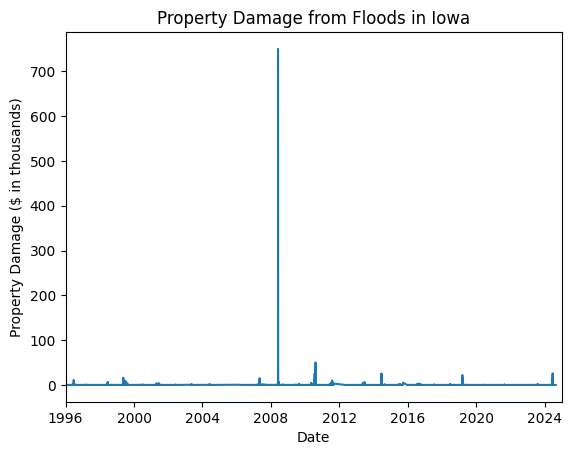

In [14]:
plt.plot(IowaFloods_96to24['DATE'], IowaFloods_96to24['DAMAGE_PROPERTY'])
plt.xlim(pd.Timestamp('1996-01-01'), pd.Timestamp('2024-12-31'))
plt.xlabel('Date')
plt.ylabel('Property Damage ($ in thousands)')
plt.title('Property Damage from Floods in Iowa')
plt.show()

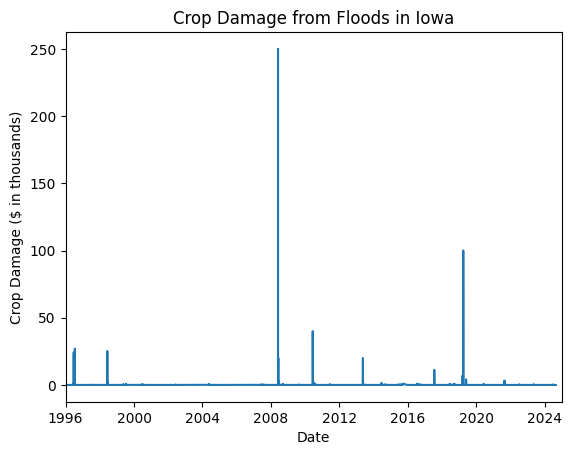

In [15]:
plt.plot(IowaFloods_96to24['DATE'], IowaFloods_96to24['DAMAGE_CROPS'])
plt.xlim(pd.Timestamp('1996-01-01'), pd.Timestamp('2024-12-31'))
plt.xlabel('Date')
plt.ylabel('Crop Damage ($ in thousands)')
plt.title('Crop Damage from Floods in Iowa')
plt.show()

In [16]:
IowaFloods_96to24['COUNT'] = range(1, len(IowaFloods_96to24) + 1) 

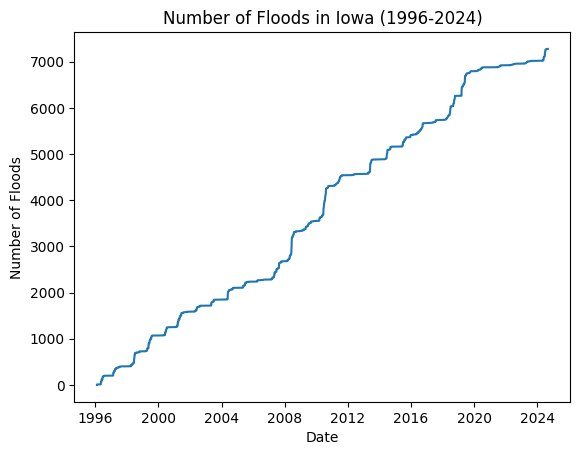

In [17]:
plt.plot(IowaFloods_96to24['DATE'], IowaFloods_96to24['COUNT'])
plt.xlabel('Date')
plt.ylabel('Number of Floods')
plt.title('Number of Floods in Iowa (1996-2024)')
plt.show()

In [34]:
countPerCounty = IowaFloods_96to24['CZ_NAME'].value_counts()
nameCounty = countPerCounty.index
countCounty = countPerCounty.values
print(countPerCounty)

CZ_NAME
POLK          294
BLACK HAWK    200
CLAY          188
CLAYTON       183
DALLAS        174
             ... 
JEFFERSON      23
MONONA         23
PAGE           23
OSCEOLA        12
SHELBY          5
Name: count, Length: 99, dtype: int64


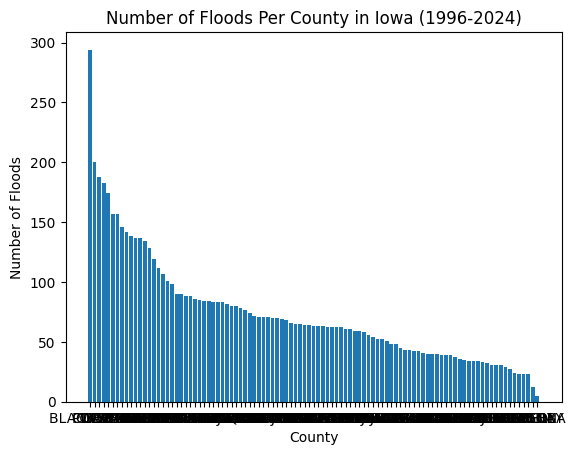

In [38]:
plt.bar(nameCounty, countCounty)
plt.xlabel('County')
plt.ylabel('Number of Floods')
plt.title('Number of Floods Per County in Iowa (1996-2024)')
plt.show()